### Run this to add the model to nobackup
just run 
source setup.sh in the terminal

### Load the model 

In [ ]:
import open_clip
import torch

 
# Load ViT-B/32 with OpenAI pretrained weights (downloads once, then cached)
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
tokenizer = open_clip.get_tokenizer('ViT-B-32')
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

 
print(f"Model loaded on: {device}")
print(f"Image preprocessing: {preprocess}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

### dataset

playing around with the data. use this block to see how the data is structured

In [2]:
import json

with open("data/dataset_rsicd.json", "r") as f:
    data = json.load(f)
images = data["images"][0]
dataset = data["dataset"][-1]


# print(json.dumps(images, indent=2))
# caption_counts = [len(img["sentences"]) for img in data["images"]]
# print(images["split"])
k = data["images"][6230]
print(k["split"])

val


#### split the data into training, valiadtion and test

In [3]:
data_a = [i for i in data["images"] if i["split"] == "train"]
data_b = [i for i in data["images"] if i["split"] == "val"]
data_c = [i for i in data["images"] if i["split"] == "test"]

print(len(data_a))
print(len(data_b))
print(len(data_c))


#data_a[25]['sentences']


8734
1094
1093


### Get an image and the captions

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

example = data_a[0]
img = Image.open(f"data/RSICD_images/{example['filename']}")

plt.imshow(img)
plt.title(example["filename"])
plt.axis("off")
plt.show()

for s in example["sentences"]:
    print(f"- {s['raw']}")

In [ ]:
import os
print(os.listdir("data/"))
missing = [img["filename"] for img in data_c if not os.path.exists(f"data/RSICD_images/{img['filename']}")]
print(f"Missing: {len(missing)} out of {len(data_c)}")
print(f"Total images: {len(os.listdir('data/RSICD_images'))}")

In [ ]:
pairs = []
for img in data_b:
    path = f"data/RSICD_images/{img['filename']}"
    if os.path.exists(path):
        for sent in img["sentences"]:
            pairs.append((path, sent["raw"]))
print(pairs)
#print(f"Total training pairs: {len(pairs)}")


In [ ]:
!pip install scikit-learn

In [8]:
from sklearn.model_selection import train_test_split

image_files = list(set([p[0] for p in pairs]))
train_imgs, val_imgs = train_test_split(image_files, test_size=0.2, random_state=42) # 80 procent training, 

train_pairs = [(p, c) for p, c in pairs if p in set(train_imgs)]
val_pairs = [(p, c) for p, c in pairs if p in set(val_imgs)]

### lets start with the embeddings

each image has the shape torch.Size([1, 3, 224, 224])
and the text has (training data right now) [1639 ,77] meaning we have [num text, tokens], 77 is the max and whats left after tokenisation will be padded

In [25]:
from rsiddataset import RSIDCDataset
from torch.utils.data import DataLoader

batch_size = 8
train_dataload = RSIDCDataset(pairs =train_pairs, preprocess=preprocess, tokenizer=tokenizer)
val_dataload = RSIDCDataset(pairs =val_pairs, preprocess=preprocess, tokenizer=tokenizer)
image = preprocess(Image.open(f"data/RSICD_images/{example['filename']}")).unsqueeze(0)
train = DataLoader(train_dataload, batch_size=batch_size, shuffle = True) # shuffle makes us shuffle data each epoch 
val =  DataLoader(val_dataload, batch_size=batch_size, shuffle = False) 



### Training loop 

some nice things to know, i know Dr J.AlmQ doesent like messy notebooks so i remove all my prints from the block and add important stuff here. 

images.shape   # (8, 3, 224, 224)

tokens.shape   # (8, 77)

image = model.encode_image(images)  has shape ([8, 512])

text  = model.encode_text(tokens) # ([8, 512])

calc = image @text.T  # [8, 512] @ [512,8] = [8,8] so a predictino for each batch



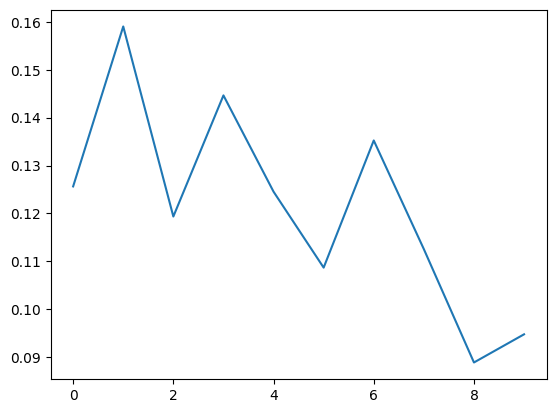

In [ ]:

loss_func = torch.nn.functional.cross_entropy
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
loss_list = []
epochs = 10 
for i in range(epochs):
    epoch_loss = 0
    for images, tokens in train:
        optimizer.zero_grad()
        labels = torch.arange(images.shape[0]).to(device)
        images = images.to(device)
        tokens = tokens.to(device)
        image = model.encode_image(images) # ([8, 512])
        text  = model.encode_text(tokens) # ([8, 512])
        logit_scale = model.logit_scale.exp() # use for scaling
        image = image / image.norm(dim=-1, keepdim=True) # normalize
        text = text / text.norm(dim=-1, keepdim=True)   
        pred = logit_scale * image @ text.T # [8, 512] @ [512,8] = [8,8] so a predictino for each batch
        loss = loss_func(pred,labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train)
    loss_list.append(avg_loss)

plt.plot(loss_list)
plt.show()